✅ Model loaded successfully from gpm_unet_model_final.h5
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 160, 180, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 160, 180, 32  320         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 160, 180, 32  9248        ['conv2d[0][0]']                 
                                )    

c:\Users\sayhe\anaconda3\envs\gpm_final\lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved prediction map: AI_Prediction_TimeStep750.png


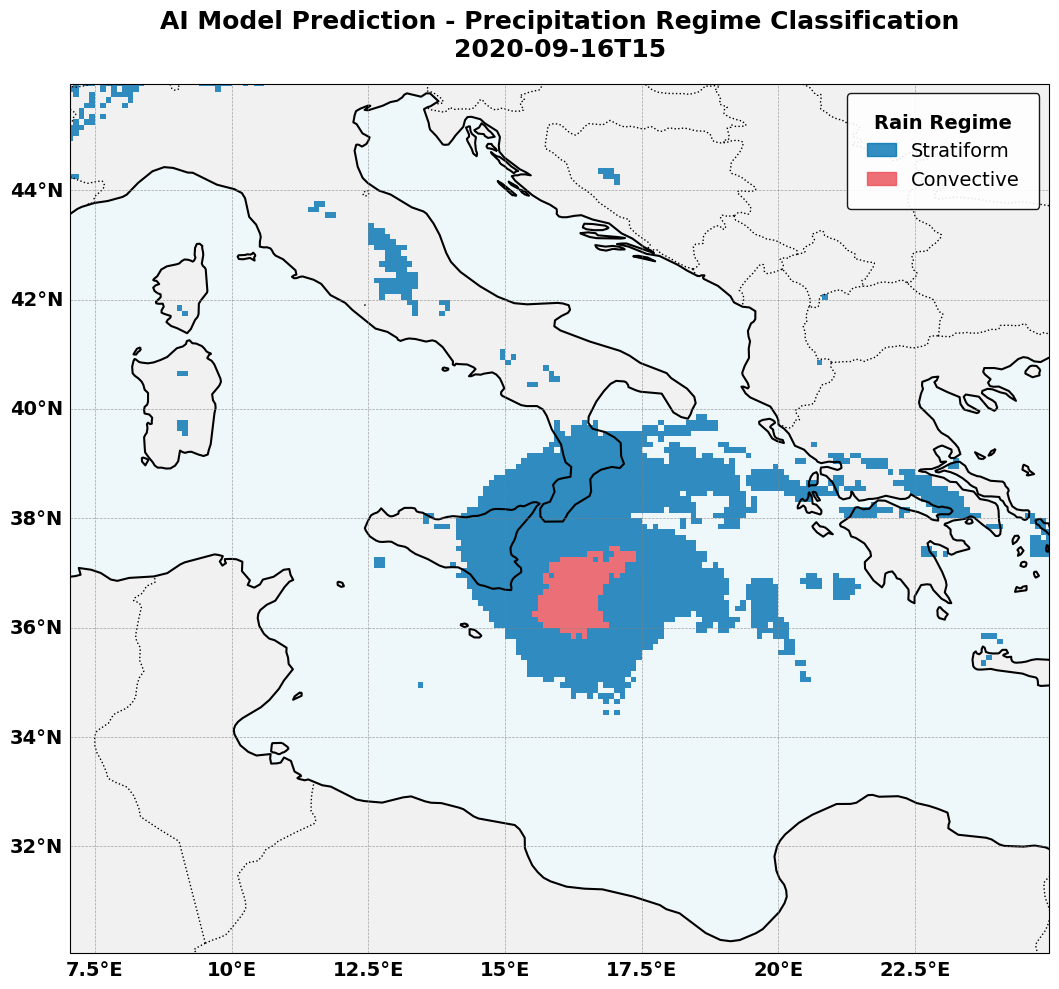

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import tensorflow as tf
from datetime import datetime

def load_trained_model(model_path):
    """
    Loads a saved Keras model from an .h5 file.
    """
    try:
        # Load the model
        model = tf.keras.models.load_model(model_path)
        print(f" Model loaded successfully from {model_path}")
        model.summary()  # Display architecture
        return model
    except Exception as e:
        print(f" Error loading model: {e}")
        return None

def prepare_single_timestep(nc_file_path, time_index=750):
    """
    Loads and prepares a single timestep from the NetCDF file for prediction.
    Returns the prepared data, timestamp string, and original shape.
    """
    ds = xr.open_dataset(nc_file_path)
    
    # Find the precipitation variable
    var_name = 'precipitationCal'  # Common name for IMERG
    if var_name not in ds:
        # Try other common names
        for test_name in ['precipitation', 'rain', 'precip', 'precipitation_rate']:
            if test_name in ds:
                var_name = test_name
                break
        if var_name not in ds:
            var_name = list(ds.data_vars)[0]  # Fallback to first variable
    
    print(f"✓ Using variable: '{var_name}'")
    
    # Select the single timestep
    data_slice = ds[var_name].isel(time=time_index).values
    
    # Handle transposing if needed
    if data_slice.shape[0] > data_slice.shape[1]:
        data_slice = data_slice.T
    
    # Get coordinates for plotting
    try:
        # Try different common coordinate names
        if 'lat' in ds and 'lon' in ds:
            lats = ds['lat'].values
            lons = ds['lon'].values
        elif 'latitude' in ds and 'longitude' in ds:
            lats = ds['latitude'].values
            lons = ds['longitude'].values
        else:
            # Check dimensions
            dims = list(ds[var_name].dims)
            if len(dims) >= 2:
                lat_dim = dims[-2] if 'lat' in dims[-2] else dims[-2]
                lon_dim = dims[-1] if 'lon' in dims[-1] else dims[-1]
                lats = ds[lat_dim].values
                lons = ds[lon_dim].values
            else:
                raise ValueError("Cannot determine lat/lon coordinates")
        
        # Check if coordinates need transposing too
        if len(lats) == data_slice.shape[1] and len(lons) == data_slice.shape[0]:
            lats, lons = lons, lats  # Swap if dimensions are reversed
            
        extent = [lons.min(), lons.max(), lats.min(), lats.max()]
        print(f"✓ Extent: Lon {lons.min():.2f} to {lons.max():.2f}, Lat {lats.min():.2f} to {lats.max():.2f}")
        
        # Create meshgrid for pcolormesh
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        
    except Exception as e:
        print(f" Could not extract coordinates: {e}")
        print(" Using default Medicane Ianos extent")
        extent = [7.5, 25, 30, 46]  # Fallback to Medicane Ianos extent
        lon_grid, lat_grid = None, None
    
    # Ensure data is 2D
    if data_slice.ndim > 2:
        data_slice = data_slice.squeeze()
    
    # Apply log1p transformation (as in your training)
    data_prepared = np.log1p(data_slice)
    
    # Add batch and channel dimensions for model
    data_for_model = data_prepared[np.newaxis, ..., np.newaxis]
    
    # Get time info
    if 'time' in ds:
        time_val = ds['time'].isel(time=time_index).values
        # Convert to readable string
        try:
            if hasattr(time_val, 'item'):
                if isinstance(time_val.item(), datetime):
                    time_str = time_val.item().strftime('%Y-%m-%d %H:%M UTC')
                else:
                    time_str = np.datetime_as_string(time_val, unit='h')
            else:
                time_str = str(time_val)
        except:
            time_str = str(time_val)
    else:
        time_str = f"Time step {time_index}"
    
    return data_for_model, time_str, data_slice.shape, lon_grid, lat_grid, extent

def predict_single_timestep(model, input_data):
    """
    Runs prediction on the prepared single timestep data.
    """
    predictions = model.predict(input_data, verbose=0)
    # Get class with highest probability for each pixel
    predicted_class = np.argmax(predictions, axis=-1)[0]  # Shape: (height, width)
    return predicted_class

def plot_prediction_map(prediction_map, lon_grid, lat_grid, extent, timestamp, 
                        save_path="AI_Prediction_Map.png"):
    """
    Plots the model prediction on a geographic map with proper styling.
    Background class (0) is completely hidden, only shows:
    - Stratiform (1) in blue
    - Convective (2) in red
    """
    
    # Create masked arrays to hide background (0)
    # Create separate masks for each class
    stratiform_mask = np.ma.masked_where(prediction_map != 1, prediction_map)
    convective_mask = np.ma.masked_where(prediction_map != 2, prediction_map)
    
    # Create figure with basemap
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Set map extent and add features
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Add geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.5, color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1.0, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
    
    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.7, 
                     linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14, 'weight': 'bold'}
    gl.ylabel_style = {'size': 14, 'weight': 'bold'}
    
    # Plot the prediction data
    if lon_grid is not None and lat_grid is not None:
        # Plot stratiform (blue) - using pcolormesh for irregular grids
        im1 = ax.pcolormesh(lon_grid, lat_grid, stratiform_mask, 
                           cmap=mcolors.ListedColormap(['#0072b2']), 
                           vmin=0, vmax=2, shading='auto', 
                           transform=ccrs.PlateCarree(), alpha=0.8)
        
        # Plot convective (red)
        im2 = ax.pcolormesh(lon_grid, lat_grid, convective_mask, 
                           cmap=mcolors.ListedColormap(['#eb4d55']), 
                           vmin=0, vmax=2, shading='auto', 
                           transform=ccrs.PlateCarree(), alpha=0.8)
    else:
        # If no lon/lat grid, use imshow with extent
        # First create a colored array where background is transparent
        colored_array = np.zeros((*prediction_map.shape, 4))  # RGBA array
        
        # Set stratiform pixels to blue
        stratiform_indices = prediction_map == 1
        colored_array[stratiform_indices] = [0, 0.45, 0.7, 0.8]  # RGBA: blue with alpha
        
        # Set convective pixels to red
        convective_indices = prediction_map == 2
        colored_array[convective_indices] = [0.92, 0.3, 0.33, 0.8]  # RGBA: red with alpha
        
        # Background pixels remain [0,0,0,0] (transparent)
        
        im = ax.imshow(colored_array, origin='lower', extent=extent, 
                      transform=ccrs.PlateCarree())
    
    # Create custom legend
    stratiform_patch = mpatches.Patch(color='#0072b2', alpha=0.8, 
                                     label=f'Stratiform')
    convective_patch = mpatches.Patch(color='#eb4d55', alpha=0.8, 
                                     label=f'Convective')
    
    # Add legend with larger font
    legend = ax.legend(handles=[stratiform_patch, convective_patch], 
                      loc='upper right', fontsize=14, framealpha=0.9, 
                      borderpad=1.0, handlelength=1.5, edgecolor='black')
    legend.set_title('Rain Regime', prop={'size': 14, 'weight': 'bold'})
    
    # Add title with larger font
    title_text = f'AI Model Prediction - Precipitation Regime Classification\n{timestamp}'
    ax.set_title(title_text, fontsize=18, fontweight='bold', pad=20)
    
    # Add axis labels with larger font
    ax.set_xlabel('Longitude', fontsize=16, fontweight='bold', labelpad=10)
    ax.set_ylabel('Latitude', fontsize=16, fontweight='bold', labelpad=10)
    '''''
    # Add text box with statistics
    total_pixels = prediction_map.size
    strat_pixels = np.sum(prediction_map == 1)
    conv_pixels = np.sum(prediction_map == 2)
    
    stats_text = (f'Total Rainy Pixels: {strat_pixels + conv_pixels}\n'
                  f'Stratiform: {strat_pixels} ({strat_pixels/total_pixels*100:.1f}%)\n'
                  f'Convective: {conv_pixels} ({conv_pixels/total_pixels*100:.1f}%)\n'
                  f'Convective Fraction: {conv_pixels/(strat_pixels+conv_pixels)*100:.1f}%')
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, 
                edgecolor='gray', linewidth=1.5)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', horizontalalignment='left',
            bbox=props)'''
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved prediction map: {save_path}")
    
    plt.show()
   

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

# 1. Load the trained model
model_path = "gpm_unet_model_final.h5"  # Your model file
model = load_trained_model(model_path)

if model is not None:
    # 2. Prepare data for time step 750
    nc_file = "Medicane_Ianos_Cropped.nc"  # Your data file
    input_data, timestamp, original_shape, lon_grid, lat_grid, extent = prepare_single_timestep(nc_file, time_index=750)
    
    print(f"\n Data prepared for: {timestamp}")
    print(f"   Input shape for model: {input_data.shape}")
    print(f"   Original data shape: {original_shape}")
    print(f"   Map extent: {extent}")
    
    # 3. Run prediction
    print("\n Running model prediction...")
    prediction_map = predict_single_timestep(model, input_data)
    
    print(f"\n Prediction complete!")
    print(f"   Prediction map shape: {prediction_map.shape}")
    print(f"   Unique classes predicted: {np.unique(prediction_map)}")
    
    # 4. Plot the prediction with basemap
    plot_prediction_map(prediction_map, lon_grid, lat_grid, extent, timestamp,
                       save_path="AI_Prediction_TimeStep750.png")